# Gaussian Process Regression

This demo shows how to use the GaussianProcessRegressor class to regress the efficiency of three-jet events with MET < 50, given the following nuisance parameters:
- $\nu^{j_1}$: jet energy scale of the leading jet, j1
- $\nu^{j_{2,3}}$: jet energy scale of the two softer jets, j2 & j3

And the following selection criteria:
- (j1_pT/$\nu^{j_1}$ > 200 GeV) & (j2_pT/$\nu^{j_{2,3}}$ < 200 GeV)
- MET < 50 GeV

The functions used to calculate the efficiency and MET can be found in obj_functions.py  
Derivative information is used to improve the regression results. 

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import h5py 
from multiprocessing import Pool, cpu_count
from sklearn.metrics import mean_squared_error

sys.path.append("../../../gpder")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware
from gpder.gaussian_process.warpers import GPWarper

from obj_functions import eff_MET50  # Efficiency function
from obj_functions import deff_MET50_sigmoid  # Gradient of eff_MET50 wrt nuJ
from plotting_utils import plot_gp

The s parameter controls the spread of the sigmoids used to compute the gradients. 
Larger s (s>1) will result in smoother sigmoids while smaller s (s<1) will result in steeper sigmoids.

In this demo, we use smooth sigmoids to avoid discontinuities in the gradients.

In [2]:
def eff_MET50_multi(args):
    (nuJ1, nuJ23) = args
    return eff_MET50(nuJ1, nuJ23)

def deff_MET50_sigmoid_multi(args):
    (nuJ1, nuJ23) = args
    return deff_MET50_sigmoid(nuJ1, nuJ23, s=10)

In [3]:
# # -- testing points -- # 
res = 25
X_lower = 0.5
X_upper = 1.5
# lin = np.linspace(X_lower, X_upper, res)
# nu_J_test, nu_j_test = np.meshgrid(lin, lin)
# X_test = np.vstack((nu_J_test.flatten(), nu_j_test.flatten())).T 
# y_test = Pool(cpu_count()).map(eff_MET50_multi, X_test)
# y_test = np.array(y_test).reshape(-1, 1)
# dX_test = X_test
# dy_test = Pool(cpu_count()).map(deff_MET50_sigmoid_multi, X_test)
# dy_test = np.array(dy_test)

f = h5py.File("./dataset_25res.h5", 'r')
X_test = np.array(f['X'])
y_test = np.array(f['y'])
dy_test = np.array(f['dy'])
f.close()

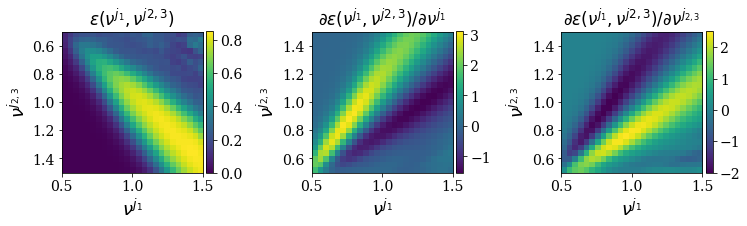

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "14"

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(wspace=0.47)

subplots_titles=[r'$\epsilon(\nu^{j_1}, \nu^{j2,3})$',
                 r"${\partial\epsilon(\nu^{j_1}, \nu^{j2,3})} / {\partial \nu^{j_1}}$", 
                 r"${\partial\epsilon(\nu^{j_1}, \nu^{j2,3})} / {\partial \nu^{j_{2,3}}}$"]

im = ax[0].imshow(y_test.reshape(res, res), 
                  origin='upper', 
                  extent=[X_lower, X_upper, X_upper, X_lower])
cbar = fig.colorbar(im, ax=ax[0], shrink=0.65, pad=0.02)
ax[0].set_title(subplots_titles[0])
ax[0].set_xlabel(r'$\nu^{j_1}$', fontsize=18)
ax[0].set_ylabel(r'$\nu^{j_{2,3}}$', fontsize=18)
ax[0].tick_params(axis='both', which='major')

n = len(X_test)
for i in [1, 2]:    
    im = ax[i].imshow(dy_test[:, i-1].reshape(res, res), 
                      origin='lower', 
                      extent=[X_lower, X_upper, X_lower, X_upper])
    cbar = fig.colorbar(im, ax=ax[i], shrink=0.65, pad=0.02)
    ax[i].set_title(subplots_titles[i])
    ax[i].set_xlabel(r'$\nu^{j_1}$', fontsize=18)
    ax[i].set_ylabel(r'$\nu^{j_{2,3}}$', fontsize=18)
    ax[i].tick_params(axis='both', which='major')
plt.show()
    

## Regular GP regression

In [5]:
# -- training points -- # 
nu_J_train = [0.7, 1.0, 1.0, 1.0, 1.3]
nu_j_train = [1.0, 0.7, 1.0, 1.3, 1.0]
X_train = np.vstack((nu_J_train, nu_j_train)).T
y_train = Pool(cpu_count()).map(eff_MET50_multi, X_train)
y_train = np.array(y_train).reshape(-1, 1)
dX_train = X_train
dy_train = Pool(cpu_count()).map(deff_MET50_sigmoid_multi, X_train)
dy_train = np.array(dy_train)

Kernel:  0.111 * RBF(length_scale=2.34) + WhiteKernel(noise_level=0.0831)
MSE :  0.07520118517295699
Uncert :  10.973232231571068


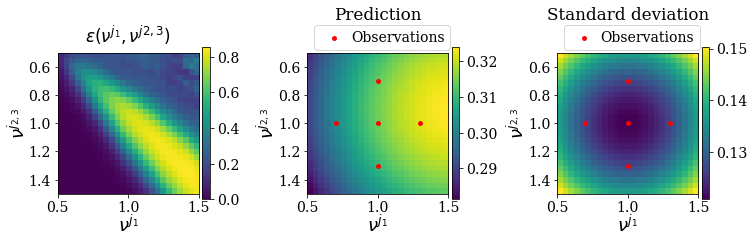

In [6]:
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              alpha=0,
                              n_restarts_optimizer=30,
                              random_state=123)
gp.fit(X_train, y_train)
print("Kernel: ", gp.kernel_)

y_pred, y_cov = gp.predict(X_test, return_cov=True)
_, y_std = gp.predict(X_test, return_std=True)

mse = mean_squared_error(y_test, y_pred)
print("MSE : ", mse)
print("Uncert : ", np.trace(y_cov))

plot_gp(y_test, y_pred, y_std, X_train=X_train, X_lower=X_lower, X_upper=X_upper, res=res)

## Derivative-enhanced GPR

And now we use derivative information to aid the GPR.  
For comparison, we use the same five training points and the same random state.

Kernel:  0.118 * DerivativeRBF(length_scale=0.28) + WhiteKernel_X(noise_level=0.0155) + WhiteKernel_dX(noise_level=1e-05)
 ----- Function obs ----- 
MSE :  0.04178646189785985
Uncert :  11.025646088187008
 
 ----- Derivative obs ----- 
MSE :  0.5938069145944579
Uncert :  521.3781918387367


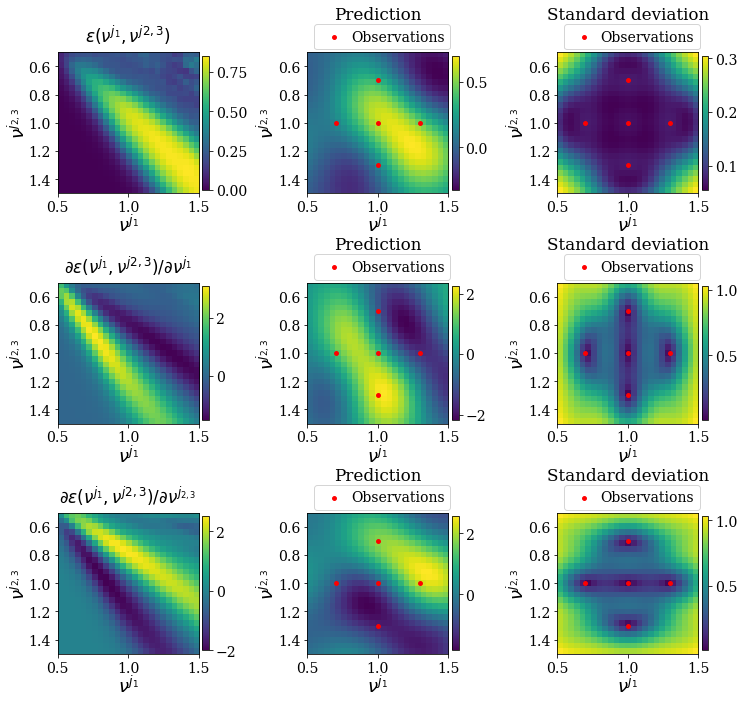

In [7]:
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              alpha=0,
                              n_restarts_optimizer=30,
                              random_state=123)
gp.fit(X_train, y_train, dX_train, dy_train,)
print("Kernel: ", gp.kernel_)

y_pred, y_cov = gp.predict(X_test, return_cov=True)
_, y_std = gp.predict(X_test, return_std=True)
mse = mean_squared_error(y_test, y_pred)
print(" ----- Function obs ----- ")
print("MSE : ", mse)
print("Uncert : ", np.trace(y_cov))
print(" ")

dy_pred, dy_cov = gp.predict_der(X_test, return_cov=True)
_, dy_std = gp.predict_der(X_test, return_std=True)
dy_mse = mean_squared_error(dy_test, dy_pred)
print(" ----- Derivative obs ----- ")
print("MSE : ", dy_mse)
print("Uncert : ", np.trace(dy_cov))

plot_gp(y_test, y_pred, y_std, X_train=X_train, X_lower=X_lower, X_upper=X_upper, res=res,
        dy_test=dy_test, dy_pred=dy_pred, dy_std=dy_std)

### Using only *some* derivatives

Kernel:  0.123 * DerivativeRBF(length_scale=0.293) + WhiteKernel_X(noise_level=0.0242) + WhiteKernel_dX(noise_level=1e-05)
 ----- Function obs ----- 
MSE :  0.04457174499412797
Uncert :  19.626765658599957
 
 ----- Derivative obs ----- 
MSE :  0.6718107431682617
Uncert :  313.3761175960166
 
 
Using only the derivative wrt $\nu^{j_1}$


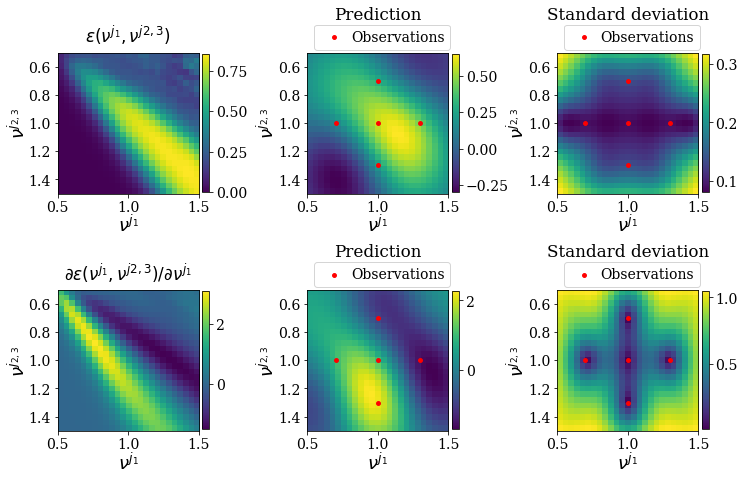

In [8]:
grad_index = 0 # use only the derivative wrt nu_J1

kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              alpha=0,
                              #optimizer=None,
                              n_restarts_optimizer=30,
                              random_state=123)
gp.fit(X_train, y_train, dX_train, dy_train[:, grad_index], idX=[grad_index])
print("Kernel: ", gp.kernel_)

y_pred, y_cov = gp.predict(X_test, return_cov=True)
_, y_std = gp.predict(X_test, return_std=True)
mse = mean_squared_error(y_test, y_pred)
print(" ----- Function obs ----- ")
print("MSE : ", mse)
print("Uncert : ", np.trace(y_cov))
print(" ")

dy_pred, dy_cov = gp.predict_der(X_test, return_cov=True)
_, dy_std = gp.predict_der(X_test, return_std=True)
dy_mse = mean_squared_error(dy_test[:, grad_index], dy_pred)
print(" ----- Derivative obs ----- ")
print("MSE : ", dy_mse)
print("Uncert : ", np.trace(dy_cov))

print(" ")
print(" ")
print(r"Using only the derivative wrt $\nu^{j_1}$")
plot_gp(y_test, y_pred, y_std, X_train=X_train, X_lower=X_lower, X_upper=X_upper, res=res,
        dy_test=dy_test[:, grad_index].reshape(-1, 1), 
        dy_pred=dy_pred.reshape(-1, 1), 
        dy_std=dy_std)